<a href="https://colab.research.google.com/github/ayushman-c/kaggle-notebooks/blob/main/Explanatory/Titanic_Dataset/notebooks/baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Titanic Survival Prediction

In this model we train a baseline machine learing model usinf Logistic Regression to predict passsenger survival.

The datset has already been cleaned and processed in the previous step.

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/cleaned_titanic.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,34.5,0,0,7.8292,True,False
1,1,3,1,47.0,1,0,7.0000,False,True
2,0,2,0,62.0,0,0,9.6875,True,False
3,0,3,0,27.0,0,0,8.6625,False,True
4,1,3,1,22.0,1,1,12.2875,False,True


##Dataset Overview

we load the cleaned dataset containing only relevant and preprocessed features.

The targer variable is "Survived" , where:

- 0 = Did not survive
- 1 = Survived

In [81]:
# Dropping 'Sex' because it has a 1.0 correlation with the target, causing leakage
X = df.drop(["Survived", "Sex"], axis=1)
y = df["Survived"]

##Feature Selection

- X [features] : All columns except for survived.
- Y [target] : Survival outcome.

This separates input variable from the prediction target.

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##Train-Test-Split

We split the dataset into:
- 80% Training data - used to train the model
- 20% Testing data - used to evaluate performance

Random state ensures randomness.

In [83]:
from sklearn.linear_model import LogisticRegression

LogR = LogisticRegression(max_iter=1000)
LogR.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

##Model Training

we use logistic regresion , which is a clarification algorithm suitable for binary outcomes.

It predicts the probablity if survival and it classifies in into 0 and 1.

In [84]:
y_pred = LogR.predict(X_test)

##Predictions

The model generates predictions on unseen test data to evaluate its performance

In [85]:
print(X.columns)

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S'], dtype='object')


In [86]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy",accuracy_score(y_test, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("Classification Report")
print(classification_report(y_test, y_pred))

Accuracy 0.5952380952380952
Confusion Matrix
[[47  3]
 [31  3]]
Classification Report
              precision    recall  f1-score   support

           0       0.60      0.94      0.73        50
           1       0.50      0.09      0.15        34

    accuracy                           0.60        84
   macro avg       0.55      0.51      0.44        84
weighted avg       0.56      0.60      0.50        84



### Investigating Overfitting / Data Leakage
We will check the correlation of each feature with the 'Survived' target. If a feature has a correlation of 1.0 or very close to it, it is likely the cause of the perfect accuracy.

##Model Evaluation

###Accuracy
Measures overall correctness of the model

## Confusion Matrix
Shows:
- True Positiveness
- True Negativeness
- False Positiveness
- false Negativeness

##Clasification Reports
Includes:
- precision
- Recall
- F1-score

These metrics give deeper insight into model performance.

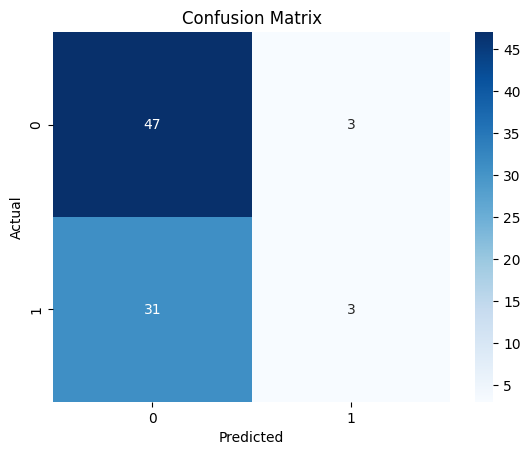

In [87]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

##Confusion Matrix Visualization

This heatmap helps visually understand how well the model is performing.

- Diagonal values = correct predeiction
- Off-diagonal values = errors

In [88]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": LogR.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

display(coefficients)

,Feature,Coefficient
5,Embarked_Q,1.119793
3,Parch,0.201912
2,SibSp,0.145269
4,Fare,0.004677
1,Age,-0.006374
6,Embarked_S,-0.119486
0,Pclass,-0.323372


## Feature Importance

Logictic Regresion assigns weights to each feature.

- positive values - increased survival probablity
- negative values - decrease survival probablity

This helps interpret model behavior.